In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

UNI_LIST = ['Bridgewater', 'Fitchburg', 'Framingham', 'MCLA', 'Salem', 'UMass Amherst', 'UMass Boston', 'UMass Lowell', 'UMass Dartmouth', 'Westfield', 'Worcester']
RAW = 'Four Year Heatmap.xlsx'

tallys = pd.read_excel(RAW, 'Tallys', header=None)
potential = tallys[tallys[0].str.contains('Potential', na=False)].copy()
potential['uni'] = potential[0].str.replace(' Potential', '', regex=False).replace({
    'Amherst': 'UMass Amherst',
    'Boston':  'UMass Boston',
    'Dartmouth': 'UMass Dartmouth',
    'Lowell':  'UMass Lowell',
})
potential = potential.set_index('uni').reindex(UNI_LIST)

df = pd.DataFrame({
    'University': UNI_LIST,
    'Computing':  potential[5].values,
    'Math':       potential[6].values,
    'Science':    potential[7].values,
    'Non-STEM':   potential[8].values,
})

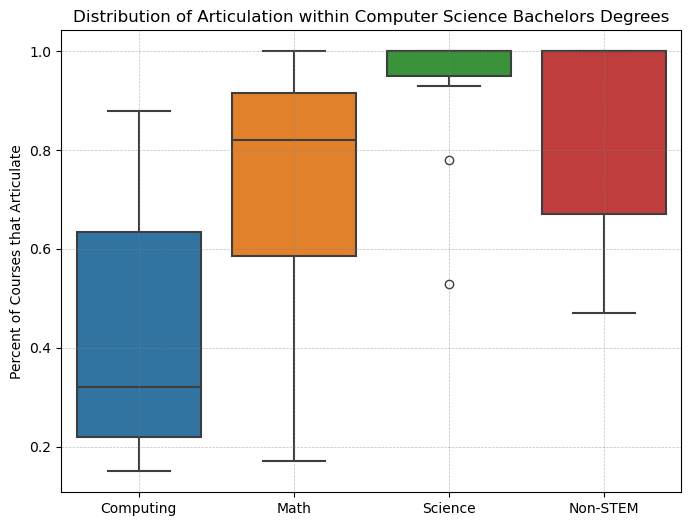

In [5]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, linewidth=1.5, zorder=1)

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.title("Distribution of Articulation within Computer Science Bachelors Degrees")
plt.ylabel("Percent of Courses that Articulate")
plt.xticks(fontsize=10) 
plt.yticks(fontsize=10)
plt.savefig('images/field_distribution.png', bbox_inches = 'tight')
plt.show()